connect drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


install g down

In [ ]:
!pip install gdown

Download ZIP File from  Link

In [ ]:
import gdown

file_id = "1c2g2lPItOTa7RnkSbtOhaUcxuQLSO5yj"
url = f"https://drive.google.com/uc?id={file_id}"

output = "/content/tomato_dataset.zip"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1c2g2lPItOTa7RnkSbtOhaUcxuQLSO5yj
From (redirected): https://drive.google.com/uc?id=1c2g2lPItOTa7RnkSbtOhaUcxuQLSO5yj&confirm=t&uuid=39409ea9-98f8-4605-9ef2-40137b1cc5a1
To: /content/tomato_dataset.zip
100%|██████████| 171M/171M [00:01<00:00, 94.3MB/s]


'/content/tomato_dataset.zip'

Unzip Dataset

In [ ]:
import zipfile
import os

zip_path = "/content/tomato_dataset.zip"
extract_path = "/content/tomato_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
print(os.listdir(extract_path))

Dataset extracted successfully.
['tomato_leaf']


check data set

In [ ]:
for root, dirs, files in os.walk(extract_path):
    print(root, "->", len(files), "files")

/content/tomato_dataset -> 0 files
/content/tomato_dataset/tomato_leaf -> 0 files
/content/tomato_dataset/tomato_leaf/Tomato___Leaf_Mold -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Bacterial_spot -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Spider_mites Two-spotted_spider_mite -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Early_blight -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Tomato_Yellow_Leaf_Curl_Virus -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Tomato_mosaic_virus -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Septoria_leaf_spot -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___healthy -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Late_blight -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Target_Spot -> 1000 files


Split Dataset 70% Train, 15% Validation, 15% Test

In [ ]:
import os
import shutil
import random

dataset_path = "/content/tomato_dataset/tomato_leaf"
split_path = "/content/tomato_split_dataset"

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

random.seed(42)

for split in ["train", "validation", "test"]:
    os.makedirs(os.path.join(split_path, split), exist_ok=True)

classes = [
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("Classes found:", classes)

for class_name in classes:
    class_dir = os.path.join(dataset_path, class_name)

    images = [
        img for img in os.listdir(class_dir)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(images)

    total = len(images)
    train_count = int(total * train_ratio)
    val_count = int(total * val_ratio)

    train_images = images[:train_count]
    val_images = images[train_count:train_count + val_count]
    test_images = images[train_count + val_count:]

    for split_name, split_images in [
        ("train", train_images),
        ("validation", val_images),
        ("test", test_images)
    ]:
        output_dir = os.path.join(split_path, split_name, class_name)
        os.makedirs(output_dir, exist_ok=True)

        for img in split_images:
            src = os.path.join(class_dir, img)
            dst = os.path.join(output_dir, img)
            shutil.copy(src, dst)

print("Dataset split completed.")

Classes found: ['Tomato___Leaf_Mold', 'Tomato___Bacterial_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Early_blight', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___Septoria_leaf_spot', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Target_Spot']
Dataset split completed.


Check Split Count

In [ ]:
for split in ["train", "validation", "test"]:
    print("\n" + split.upper())

    split_dir = os.path.join(split_path, split)

    for class_name in os.listdir(split_dir):
        class_dir = os.path.join(split_dir, class_name)
        print(class_name, ":", len(os.listdir(class_dir)))


TRAIN
Tomato___Leaf_Mold : 700
Tomato___Bacterial_spot : 700
Tomato___Spider_mites Two-spotted_spider_mite : 700
Tomato___Early_blight : 700
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 700
Tomato___Tomato_mosaic_virus : 700
Tomato___Septoria_leaf_spot : 700
Tomato___healthy : 700
Tomato___Late_blight : 700
Tomato___Target_Spot : 700

VALIDATION
Tomato___Leaf_Mold : 150
Tomato___Bacterial_spot : 150
Tomato___Spider_mites Two-spotted_spider_mite : 150
Tomato___Early_blight : 150
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 150
Tomato___Tomato_mosaic_virus : 150
Tomato___Septoria_leaf_spot : 150
Tomato___healthy : 150
Tomato___Late_blight : 150
Tomato___Target_Spot : 150

TEST
Tomato___Leaf_Mold : 150
Tomato___Bacterial_spot : 150
Tomato___Spider_mites Two-spotted_spider_mite : 150
Tomato___Early_blight : 150
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 150
Tomato___Tomato_mosaic_virus : 150
Tomato___Septoria_leaf_spot : 150
Tomato___healthy : 150
Tomato___Late_blight : 150
Tomato___Target_Spot : 1

Load Dataset for Training



In [ ]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 32

train_dir = "/content/tomato_split_dataset/train"
val_dir = "/content/tomato_split_dataset/validation"
test_dir = "/content/tomato_split_dataset/test"

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_data = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = train_data.class_names
print("Class names:", class_names)

Found 7000 files belonging to 10 classes.
Found 1500 files belonging to 10 classes.
Found 1500 files belonging to 10 classes.
Class names: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


Improve Dataset Loading Speed

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(buffer_size=AUTOTUNE)
val_data = val_data.prefetch(buffer_size=AUTOTUNE)
test_data = test_data.prefetch(buffer_size=AUTOTUNE)

 Build MobileNetV2 Model

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

num_classes = len(class_names)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Train Model

In [ ]:
epochs = 35

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs
)

Epoch 1/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 27s 79ms/step - accuracy: 0.1794 - loss: 2.3754 - val_accuracy: 0.3720 - val_loss: 1.8709
Epoch 2/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step - accuracy: 0.3840 - loss: 1.7778 - val_accuracy: 0.5667 - val_loss: 1.4849
Epoch 3/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.5046 - loss: 1.4662 - val_accuracy: 0.6433 - val_loss: 1.2577
Epoch 4/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 76ms/step - accuracy: 0.5731 - loss: 1.2749 - val_accuracy: 0.6860 - val_loss: 1.1182
Epoch 5/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - accuracy: 0.6193 - loss: 1.1425 - val_accuracy: 0.7067 - val_loss: 1.0160
Epoch 6/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - accuracy: 0.6531 - loss: 1.0493 - val_accuracy: 0.7247 - val_loss: 0.9446
Epoch 7/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - accuracy: 0.6730 - loss: 0.9859 - val_accuracy: 0.7433 - val_loss: 0.8891
Epoch 8/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - accuracy: 0.7014 - loss: 0.9224 - 

Test Model Accuracy



In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8407 - loss: 0.5088
Test Loss: 0.5087808966636658
Test Accuracy: 0.840666651725769


accuracy imroving

In [ ]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 32

train_dir = "/content/tomato_split_dataset/train"
val_dir = "/content/tomato_split_dataset/validation"
test_dir = "/content/tomato_split_dataset/test"

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_data = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = train_data.class_names
num_classes = len(class_names)

print(class_names)

Found 7000 files belonging to 10 classes.
Found 1500 files belonging to 10 classes.
Found 1500 files belonging to 10 classes.
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().shuffle(1000).prefetch(AUTOTUNE)
val_data = val_data.cache().prefetch(AUTOTUNE)
test_data = test_data.cache().prefetch(AUTOTUNE)

build mobilenetv2

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.25),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2)
])

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,275,914 (8.68 MB)

 Trainable params: 15,370 (60.04 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install gdown

In [ ]:
import gdown

file_id = "1c2g2lPItOTa7RnkSbtOhaUcxuQLSO5yj"
url = f"https://drive.google.com/uc?id={file_id}"

output = "/content/tomato_dataset.zip"
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1c2g2lPItOTa7RnkSbtOhaUcxuQLSO5yj
From (redirected): https://drive.google.com/uc?id=1c2g2lPItOTa7RnkSbtOhaUcxuQLSO5yj&confirm=t&uuid=8008deb2-794a-40e5-9939-25617808a821
To: /content/tomato_dataset.zip
100%|██████████| 171M/171M [00:00<00:00, 192MB/s]


'/content/tomato_dataset.zip'

In [ ]:
import zipfile
import os

zip_path = "/content/tomato_dataset.zip"
extract_path = "/content/tomato_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted folders:")
print(os.listdir(extract_path))

Extracted folders:
['tomato_leaf']


In [ ]:
for root, dirs, files in os.walk(extract_path):
    print(root, "->", len(files), "files")

/content/tomato_dataset -> 0 files
/content/tomato_dataset/tomato_leaf -> 0 files
/content/tomato_dataset/tomato_leaf/Tomato___Leaf_Mold -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Bacterial_spot -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Spider_mites Two-spotted_spider_mite -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Early_blight -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Tomato_Yellow_Leaf_Curl_Virus -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Tomato_mosaic_virus -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Septoria_leaf_spot -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___healthy -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Late_blight -> 1000 files
/content/tomato_dataset/tomato_leaf/Tomato___Target_Spot -> 1000 files


In [ ]:
dataset_path = "/content/tomato_dataset/tomato_leaf"

In [ ]:
import os
import shutil
import random

dataset_path = "/content/tomato_dataset/tomato_leaf"
split_path = "/content/tomato_split_dataset"

train_ratio = 0.70
val_ratio = 0.15

random.seed(42)

if os.path.exists(split_path):
    shutil.rmtree(split_path)

for split in ["train", "validation", "test"]:
    os.makedirs(os.path.join(split_path, split), exist_ok=True)

classes = [
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("Classes found:", classes)

for class_name in classes:
    class_dir = os.path.join(dataset_path, class_name)

    images = [
        img for img in os.listdir(class_dir)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(images)

    total = len(images)
    train_count = int(total * train_ratio)
    val_count = int(total * val_ratio)

    train_images = images[:train_count]
    val_images = images[train_count:train_count + val_count]
    test_images = images[train_count + val_count:]

    for split_name, split_images in [
        ("train", train_images),
        ("validation", val_images),
        ("test", test_images)
    ]:
        output_dir = os.path.join(split_path, split_name, class_name)
        os.makedirs(output_dir, exist_ok=True)

        for img in split_images:
            src = os.path.join(class_dir, img)
            dst = os.path.join(output_dir, img)
            shutil.copy(src, dst)

print("Dataset split completed.")

Classes found: ['Tomato___Leaf_Mold', 'Tomato___Bacterial_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Early_blight', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___Septoria_leaf_spot', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Target_Spot']
Dataset split completed.


In [ ]:
print(os.listdir("/content/tomato_split_dataset"))
print(os.listdir("/content/tomato_split_dataset/train"))

['validation', 'train', 'test']
['Tomato___Leaf_Mold', 'Tomato___Bacterial_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Early_blight', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___Septoria_leaf_spot', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Target_Spot']


In [ ]:
for split in ["train", "validation", "test"]:
    print("\n" + split.upper())

    split_dir = os.path.join(split_path, split)

    for class_name in os.listdir(split_dir):
        class_dir = os.path.join(split_dir, class_name)
        print(class_name, ":", len(os.listdir(class_dir)))


TRAIN
Tomato___Leaf_Mold : 700
Tomato___Bacterial_spot : 700
Tomato___Spider_mites Two-spotted_spider_mite : 700
Tomato___Early_blight : 700
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 700
Tomato___Tomato_mosaic_virus : 700
Tomato___Septoria_leaf_spot : 700
Tomato___healthy : 700
Tomato___Late_blight : 700
Tomato___Target_Spot : 700

VALIDATION
Tomato___Leaf_Mold : 150
Tomato___Bacterial_spot : 150
Tomato___Spider_mites Two-spotted_spider_mite : 150
Tomato___Early_blight : 150
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 150
Tomato___Tomato_mosaic_virus : 150
Tomato___Septoria_leaf_spot : 150
Tomato___healthy : 150
Tomato___Late_blight : 150
Tomato___Target_Spot : 150

TEST
Tomato___Leaf_Mold : 150
Tomato___Bacterial_spot : 150
Tomato___Spider_mites Two-spotted_spider_mite : 150
Tomato___Early_blight : 150
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 150
Tomato___Tomato_mosaic_virus : 150
Tomato___Septoria_leaf_spot : 150
Tomato___healthy : 150
Tomato___Late_blight : 150
Tomato___Target_Spot : 1

In [ ]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 32

train_dir = "/content/tomato_split_dataset/train"
val_dir = "/content/tomato_split_dataset/validation"
test_dir = "/content/tomato_split_dataset/test"

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_data = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = train_data.class_names
num_classes = len(class_names)

print(class_names)

Found 7000 files belonging to 10 classes.
Found 1500 files belonging to 10 classes.
Found 1500 files belonging to 10 classes.
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


imrove data set speed

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(AUTOTUNE)
val_data = val_data.prefetch(AUTOTUNE)
test_data = test_data.prefetch(AUTOTUNE)

mobile net v2

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.25),
    layers.RandomContrast(0.2)
])

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,275,914 (8.68 MB)

 Trainable params: 15,370 (60.04 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

add call back

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/best_tomato_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

training

In [ ]:
initial_epochs = 30

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=initial_epochs,
    callbacks=callbacks
)

Epoch 1/30
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6069 - loss: 1.1443
Epoch 1: val_accuracy improved from 0.68067 to 0.71267, saving model to /content/best_tomato_model.keras

Epoch 1: finished saving model to /content/best_tomato_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.6194 - loss: 1.1141 - val_accuracy: 0.7127 - val_loss: 0.8859 - learning_rate: 1.0000e-04
Epoch 2/30
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6497 - loss: 1.0288
Epoch 2: val_accuracy improved from 0.71267 to 0.72733, saving model to /content/best_tomato_model.keras

Epoch 2: finished saving model to /content/best_tomato_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - accuracy: 0.6574 - loss: 1.0014 - val_accuracy: 0.7273 - val_loss: 0.8354 - learning_rate: 1.0000e-04
Epoch 3/30
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6705 - loss: 0.9741
Epoch 3: val_accuracy improved from 0.72733 to 0.73400, saving model to /content/best_tomato_model.

finne tuning

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_epochs = 15
total_epochs = initial_epochs + fine_tune_epochs

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1,
    callbacks=callbacks
)

Epoch 31/45
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6847 - loss: 0.9676
Epoch 31: val_accuracy did not improve from 0.83400
219/219 ━━━━━━━━━━━━━━━━━━━━ 35s 106ms/step - accuracy: 0.7153 - loss: 0.8469 - val_accuracy: 0.6513 - val_loss: 1.3107 - learning_rate: 1.0000e-05
Epoch 32/45
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7650 - loss: 0.6957
Epoch 32: val_accuracy did not improve from 0.83400
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 101ms/step - accuracy: 0.7760 - loss: 0.6525 - val_accuracy: 0.6520 - val_loss: 1.4046 - learning_rate: 1.0000e-05
Epoch 33/45
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7974 - loss: 0.6020
Epoch 33: val_accuracy did not improve from 0.83400

Epoch 33: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.8050 - loss: 0.5787 - val_accuracy: 0.7013 - val_loss: 1.1611 - learning_rate: 1.0000e-05
Epoch 34/45
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - ac

In [ ]:
best_model = tf.keras.models.load_model("/content/best_tomato_model.keras")

test_loss, test_accuracy = best_model.evaluate(test_data)

print("Improved Test Loss:", test_loss)
print("Improved Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8433 - loss: 0.4771
Improved Test Loss: 0.477061003446579
Improved Test Accuracy: 0.8433333039283752


save model and class names to g drive

In [ ]:
import json
import shutil
from google.colab import drive

drive.mount('/content/drive')

best_model.save("/content/improved_tomato_leaf_model.keras")

with open("/content/class_names.json", "w") as f:
    json.dump(class_names, f)

shutil.copy(
    "/content/improved_tomato_leaf_model.keras",
    "/content/drive/MyDrive/improved_tomato_leaf_model.keras"
)

shutil.copy(
    "/content/class_names.json",
    "/content/drive/MyDrive/class_names.json"
)

print("Improved model and class names saved to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Improved model and class names saved to Google Drive.


test image

In [ ]:
import os

test_class = class_names[0]
test_folder = os.path.join("/content/tomato_split_dataset/test", test_class)

test_image = os.path.join(test_folder, os.listdir(test_folder)[0])

print("Test image:", test_image)

Test image: /content/tomato_split_dataset/test/Tomato___Bacterial_spot/bea52a18-00de-4080-b460-4cf34c3c8688___GCREC_Bact.Sp 3499.JPG


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_leaf(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = best_model.predict(img_array)

    predicted_index = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    return class_names[predicted_index], round(confidence, 2)

disease, confidence = predict_leaf(test_image)

print("Predicted Disease:", disease)
print("Confidence:", confidence, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Disease: Tomato___Bacterial_spot
Confidence: 90.18 %


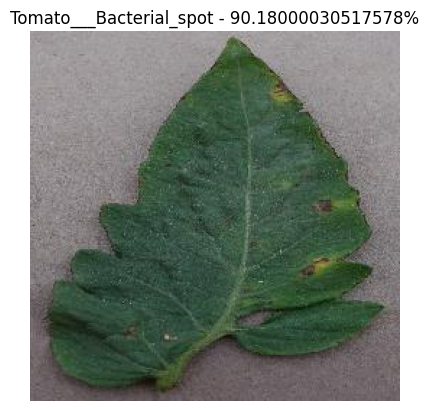

In [ ]:
import matplotlib.pyplot as plt

img = image.load_img(test_image)

plt.imshow(img)
plt.axis("off")
plt.title(f"{disease} - {confidence}%")
plt.show()

plot training accuracy and loss

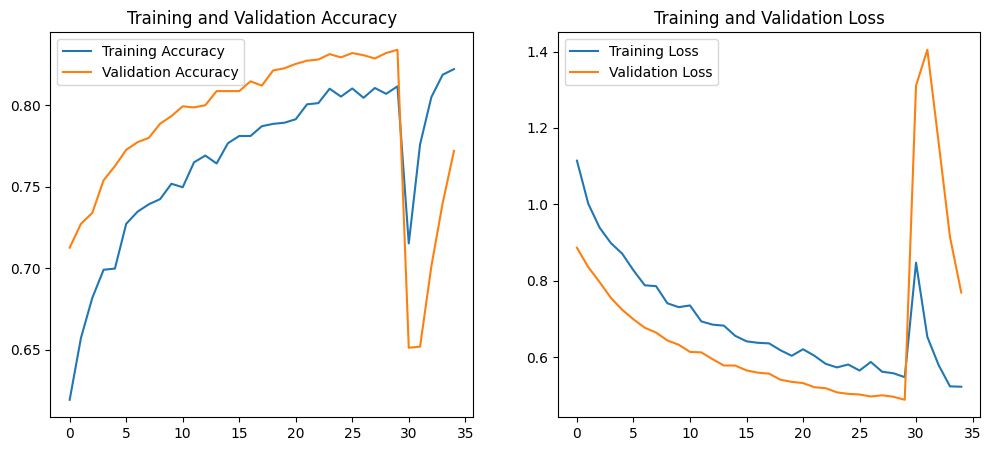

In [ ]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]

loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.show()

confution matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━

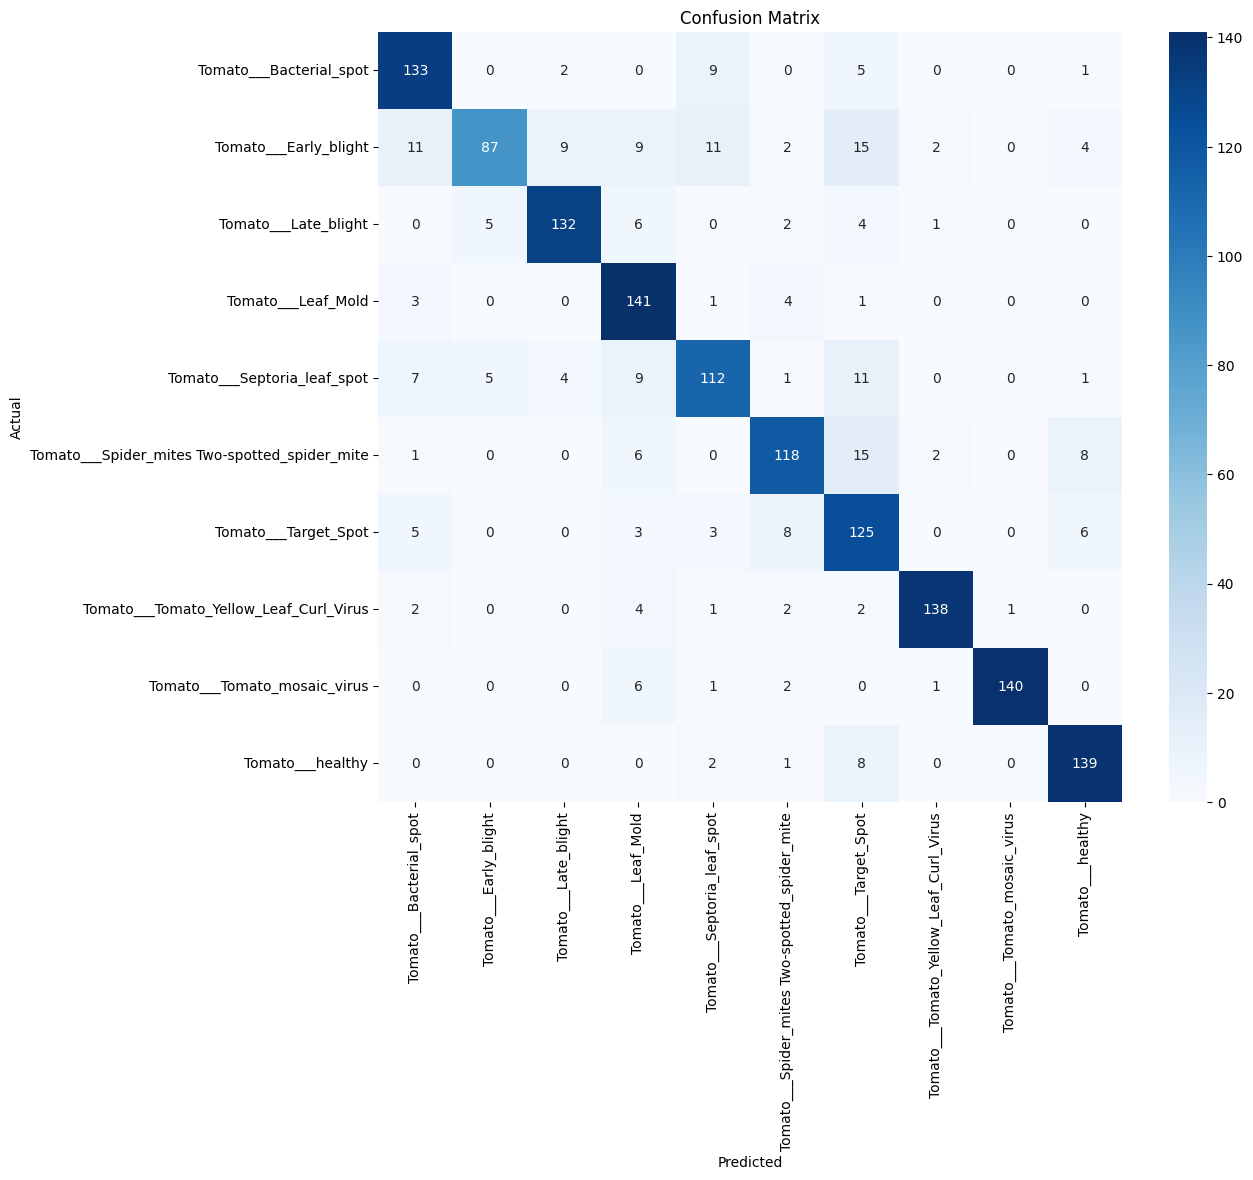

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = best_model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

 Classification Report



In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.82      0.89      0.85       150
                        Tomato___Early_blight       0.90      0.58      0.70       150
                         Tomato___Late_blight       0.90      0.88      0.89       150
                           Tomato___Leaf_Mold       0.77      0.94      0.84       150
                  Tomato___Septoria_leaf_spot       0.80      0.75      0.77       150
Tomato___Spider_mites Two-spotted_spider_mite       0.84      0.79      0.81       150
                         Tomato___Target_Spot       0.67      0.83      0.74       150
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.96      0.92      0.94       150
                 Tomato___Tomato_mosaic_virus       0.99      0.93      0.96       150
                             Tomato___healthy       0.87      0.93      0.90       150

                                     accu

Disease Severity Detection Using OpenCV

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def estimate_disease_severity(image_path):
    image = cv2.imread(image_path)

    if image is None:
        return None, None, None

    image = cv2.resize(image, (500, 500))

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    lower_leaf = np.array([20, 30, 30])
    upper_leaf = np.array([95, 255, 255])
    leaf_mask = cv2.inRange(hsv, lower_leaf, upper_leaf)

    lower_disease1 = np.array([5, 40, 40])
    upper_disease1 = np.array([30, 255, 255])
    disease_mask1 = cv2.inRange(hsv, lower_disease1, upper_disease1)

    lower_disease2 = np.array([0, 20, 20])
    upper_disease2 = np.array([20, 255, 200])
    disease_mask2 = cv2.inRange(hsv, lower_disease2, upper_disease2)

    disease_mask = cv2.bitwise_or(disease_mask1, disease_mask2)

    total_leaf_area = cv2.countNonZero(leaf_mask) + cv2.countNonZero(disease_mask)
    infected_area = cv2.countNonZero(disease_mask)

    if total_leaf_area == 0:
        severity = 0
    else:
        severity = (infected_area / total_leaf_area) * 100

    highlighted = image.copy()
    highlighted[disease_mask > 0] = [0, 0, 255]

    return round(severity, 2), image, highlighted

Disease Severity: 5.29 %


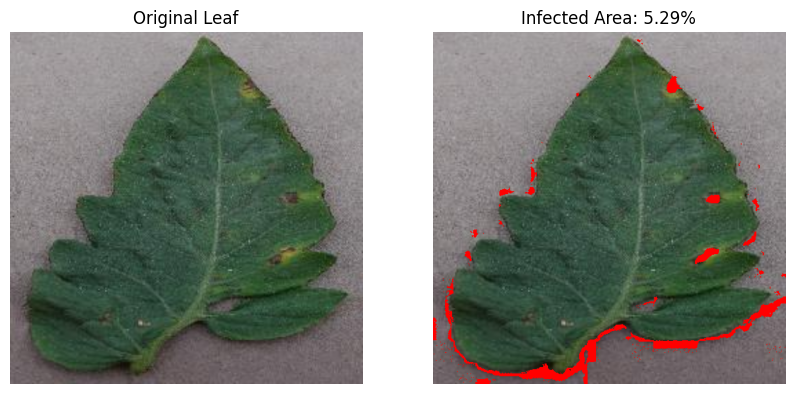

In [ ]:
severity, original, highlighted = estimate_disease_severity(test_image)

print("Disease Severity:", severity, "%")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original Leaf")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(highlighted, cv2.COLOR_BGR2RGB))
plt.title(f"Infected Area: {severity}%")
plt.axis("off")

plt.show()

save model keras

In [ ]:
best_model.save("/content/improved_tomato_leaf_model.keras")

In [ ]:
import json

with open("/content/class_names.json", "w") as f:
    json.dump(class_names, f)

In [ ]:
import shutil
from google.colab import drive

drive.mount("/content/drive")

shutil.copy(
    "/content/improved_tomato_leaf_model.keras",
    "/content/drive/MyDrive/improved_tomato_leaf_model.keras"
)

shutil.copy(
    "/content/class_names.json",
    "/content/drive/MyDrive/class_names.json"
)

print("Model and class names saved successfully to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model and class names saved successfully to Google Drive.


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/improved_tomato_leaf_model.keras")

In [ ]:
model = tf.keras.models.load_model("improved_tomato_leaf_model.keras")

In [ ]:
import shutil
from google.colab import drive

drive.mount("/content/drive")

shutil.copy(
    "/content/improved_tomato_leaf_model.keras",
    "/content/drive/MyDrive/improved_tomato_leaf_model.keras"
)

print("Saved successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved successfully.


In [ ]:
import json

with open("/content/class_names.json", "w") as f:
    json.dump(class_names, f)

shutil.copy(
    "/content/class_names.json",
    "/content/drive/MyDrive/class_names.json"
)

'/content/drive/MyDrive/class_names.json'

In [ ]:
model = tf.keras.models.load_model("improved_tomato_leaf_model.keras")

Load Saved Model

In [ ]:
import tensorflow as tf

best_model = tf.keras.models.load_model("/content/improved_tomato_leaf_model.keras")

Evaluate Test Accuracy

In [ ]:
test_loss, test_accuracy = best_model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8433 - loss: 0.4771
Test Loss: 0.477061003446579
Test Accuracy: 0.8433333039283752


Save Class Names



In [ ]:
import json

with open("/content/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names saved.")

Class names saved.


Predict One Image

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image

test_class = class_names[0]
test_folder = os.path.join("/content/tomato_split_dataset/test", test_class)
test_image = os.path.join(test_folder, os.listdir(test_folder)[0])

print("Selected image:", test_image)

def predict_leaf(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = best_model.predict(img_array)

    predicted_index = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    return class_names[predicted_index], round(float(confidence), 2)

disease, confidence = predict_leaf(test_image)

print("Predicted Disease:", disease)
print("Confidence:", confidence, "%")

Selected image: /content/tomato_split_dataset/test/Tomato___Bacterial_spot/bea52a18-00de-4080-b460-4cf34c3c8688___GCREC_Bact.Sp 3499.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Disease: Tomato___Bacterial_spot
Confidence: 90.18 %


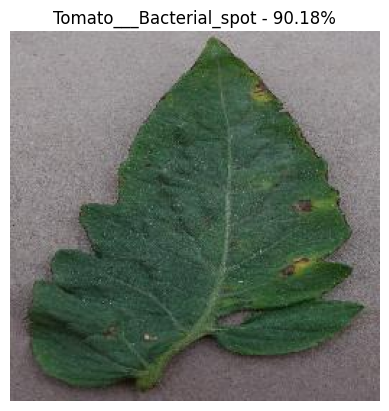

In [ ]:
import matplotlib.pyplot as plt

img = image.load_img(test_image)

plt.imshow(img)
plt.axis("off")
plt.title(f"{disease} - {confidence}%")
plt.show()

Disease Severity Estimation

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def estimate_disease_severity(image_path):
    img = cv2.imread(image_path)

    if img is None:
        return 0, None, None

    img = cv2.resize(img, (500, 500))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    lower_leaf = np.array([20, 30, 30])
    upper_leaf = np.array([95, 255, 255])
    leaf_mask = cv2.inRange(hsv, lower_leaf, upper_leaf)

    lower_disease1 = np.array([5, 40, 40])
    upper_disease1 = np.array([30, 255, 255])
    disease_mask1 = cv2.inRange(hsv, lower_disease1, upper_disease1)

    lower_disease2 = np.array([0, 20, 20])
    upper_disease2 = np.array([20, 255, 200])
    disease_mask2 = cv2.inRange(hsv, lower_disease2, upper_disease2)

    disease_mask = cv2.bitwise_or(disease_mask1, disease_mask2)

    total_leaf_area = cv2.countNonZero(leaf_mask) + cv2.countNonZero(disease_mask)
    infected_area = cv2.countNonZero(disease_mask)

    if total_leaf_area == 0:
        severity = 0
    else:
        severity = (infected_area / total_leaf_area) * 100

    highlighted = img.copy()
    highlighted[disease_mask > 0] = [0, 0, 255]

    return round(float(severity), 2), img, highlighted

Disease Severity: 5.29 %


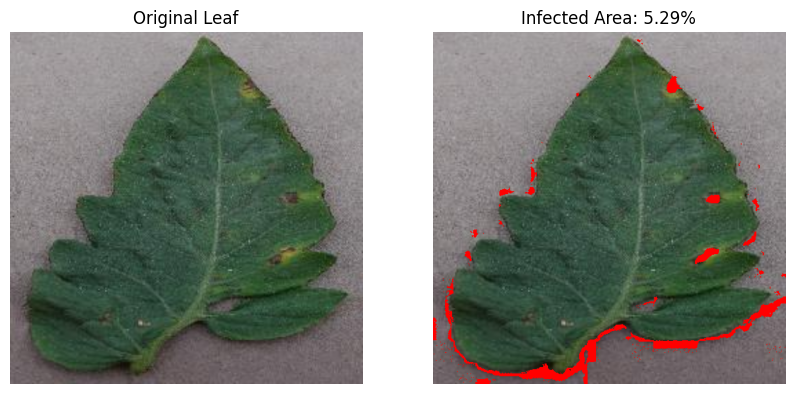

In [ ]:
severity, original, highlighted = estimate_disease_severity(test_image)

print("Disease Severity:", severity, "%")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original Leaf")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(highlighted, cv2.COLOR_BGR2RGB))
plt.title(f"Infected Area: {severity}%")
plt.axis("off")

plt.show()

Copy Final Files to Google Drive

In [ ]:
import shutil
from google.colab import drive

drive.mount("/content/drive")

shutil.copy(
    "/content/improved_tomato_leaf_model.keras",
    "/content/drive/MyDrive/improved_tomato_leaf_model.keras"
)

shutil.copy(
    "/content/class_names.json",
    "/content/drive/MyDrive/class_names.json"
)

print("Final files copied to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Final files copied to Google Drive.


Download Files to Your Computer

In [ ]:
from google.colab import files

files.download("/content/improved_tomato_leaf_model.keras")
files.download("/content/class_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>